Generating Plot 1...


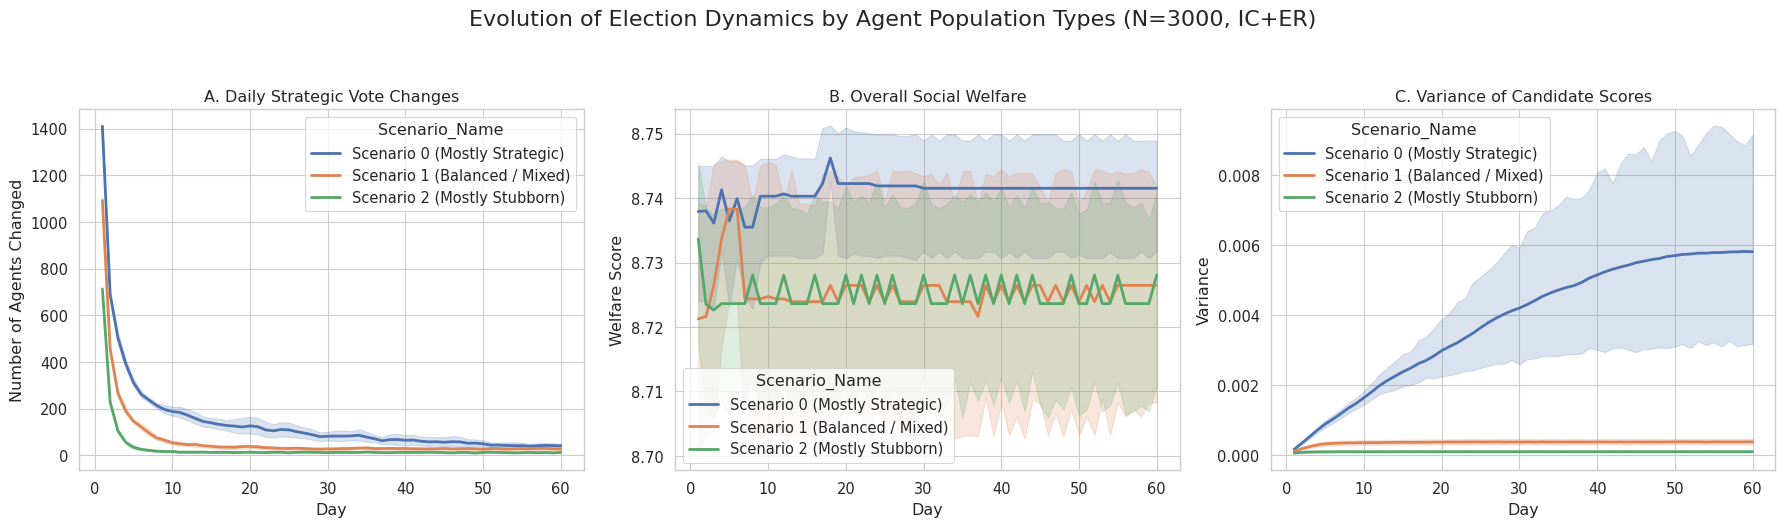

Generating Plot 2 (3 indicators)...


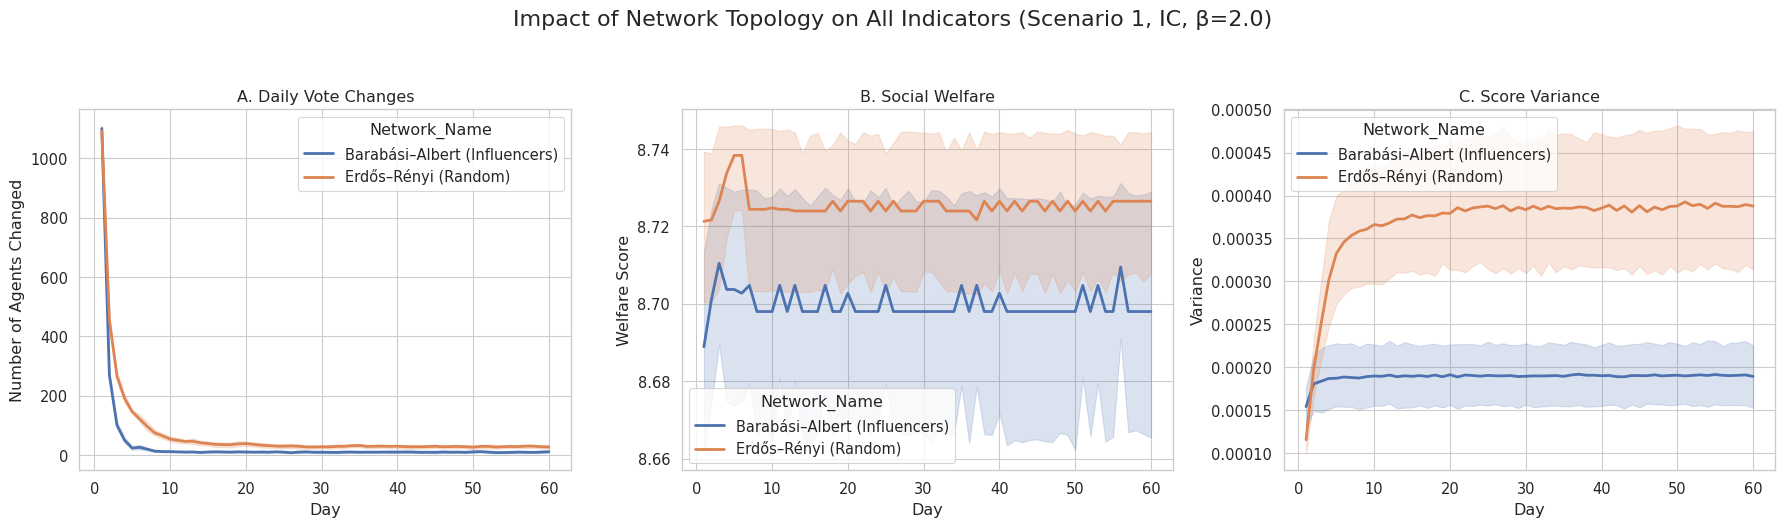

Generating Plot 3 (3 indicators)...


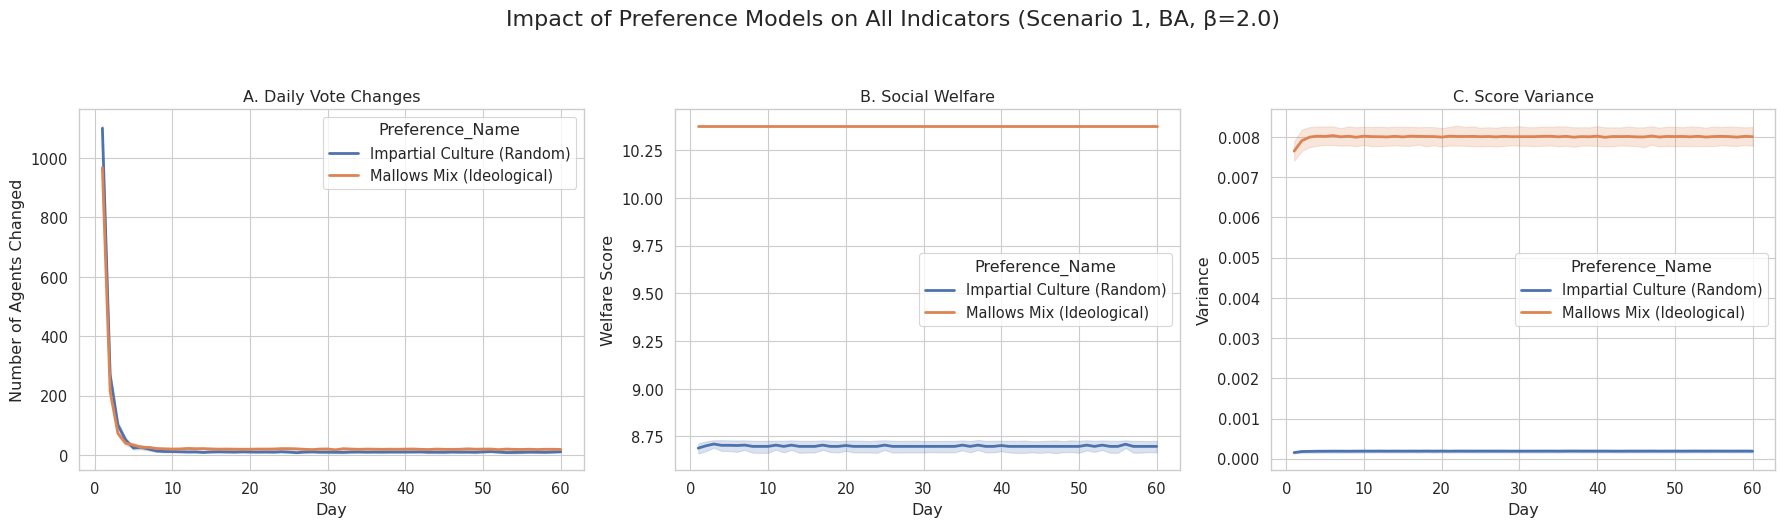

Generating Plot 4...


/tmp/ipykernel_1709/1949654572.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p4_data['Beta_Label'] = p4_data['beta'].apply(lambda x: f"Beta = {x} (High Sensitivity)" if x == 5.0 else f"Beta = {x} (Low Sensitivity)")


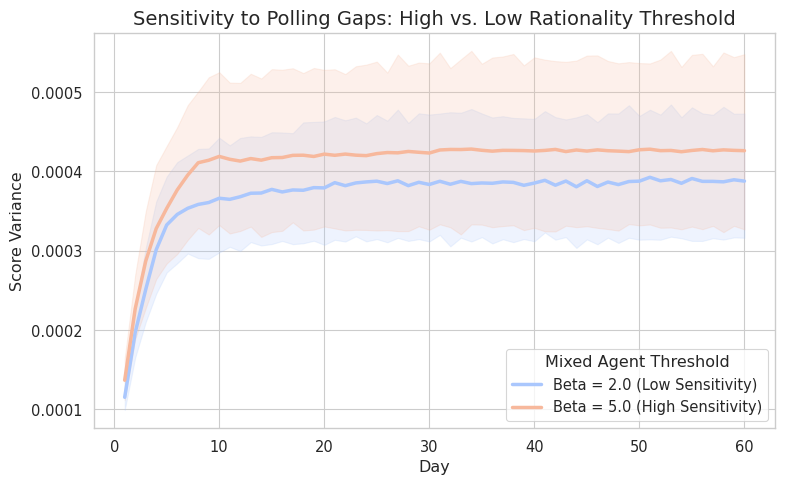


 All 4 plots generated and saved as high-resolution PNGs!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. SETUP & STYLING ───────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Load the ultimate dataset
df = pd.read_csv("surrogate_training_data_FINAL.csv")

# Create human-readable labels for the legends
df['Scenario_Name'] = df['scenario'].map({
    0: 'Scenario 0 (Mostly Strategic)',
    1: 'Scenario 1 (Balanced / Mixed)',
    2: 'Scenario 2 (Mostly Stubborn)'
})
df['Network_Name'] = df['net_code'].map({
    0: 'Erdős–Rényi (Random)',
    1: 'Barabási–Albert (Influencers)'
})
df['Preference_Name'] = df['pref_code'].map({
    0: 'Impartial Culture (Random)',
    1: 'Mallows Mix (Ideological)'
})

# To keep the lines clean, we will plot the data for N=3000 voters.
df_plot = df[df['N_voters'] == 3000]


# ── PLOT 1: THE AGENT BEHAVIOR SHOWDOWN ──────────────────────────────
print("Generating Plot 1...")
# Filter: IC Preferences, ER Network, Beta=2.0
p1_data = df_plot[(df_plot['pref_code'] == 0) &
                  (df_plot['net_code'] == 0) &
                  (df_plot['beta'] == 2.0)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evolution of Election Dynamics by Agent Population Types (N=3000, IC+ER)', fontsize=16, y=1.05)

# Panel A: Changes
sns.lineplot(data=p1_data, x='cycle', y='changes', hue='Scenario_Name', ax=axes[0], linewidth=2)
axes[0].set_title('A. Daily Strategic Vote Changes')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Number of Agents Changed')

# Panel B: Social Welfare
sns.lineplot(data=p1_data, x='cycle', y='welfare', hue='Scenario_Name', ax=axes[1], linewidth=2)
axes[1].set_title('B. Overall Social Welfare')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Welfare Score')

# Panel C: Score Variance
sns.lineplot(data=p1_data, x='cycle', y='variance', hue='Scenario_Name', ax=axes[2], linewidth=2)
axes[2].set_title('C. Variance of Candidate Scores')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Variance')

plt.tight_layout()
plt.savefig("plot1_scenarios.png", dpi=300, bbox_inches="tight")
plt.show()


# ── PLOT 2: NETWORK TOPOLOGY (FIXED - 3 SUBPLOTS) ────────────────────
print("Generating Plot 2 (3 indicators)...")
# Filter: Scenario 1 (Balanced), IC Preferences, Beta=2.0
p2_data = df_plot[(df_plot['scenario'] == 1) &
                  (df_plot['pref_code'] == 0) &
                  (df_plot['beta'] == 2.0)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impact of Network Topology on All Indicators (Scenario 1, IC, β=2.0)', fontsize=16, y=1.05)

# A: Changes
sns.lineplot(data=p2_data, x='cycle', y='changes', hue='Network_Name', ax=axes[0], linewidth=2)
axes[0].set_title('A. Daily Vote Changes')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Number of Agents Changed')

# B: Welfare
sns.lineplot(data=p2_data, x='cycle', y='welfare', hue='Network_Name', ax=axes[1], linewidth=2)
axes[1].set_title('B. Social Welfare')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Welfare Score')

# C: Variance
sns.lineplot(data=p2_data, x='cycle', y='variance', hue='Network_Name', ax=axes[2], linewidth=2)
axes[2].set_title('C. Score Variance')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Variance')

plt.tight_layout()
plt.savefig("plot2_networks_full.png", dpi=300, bbox_inches="tight")
plt.show()

# ── PLOT 3: PREFERENCE MODELS (FIXED - 3 SUBPLOTS) ───────────────────
print("Generating Plot 3 (3 indicators)...")
# Filter: Scenario 1 (Balanced), BA Network, Beta=2.0
p3_data = df_plot[(df_plot['scenario'] == 1) &
                  (df_plot['net_code'] == 1) &
                  (df_plot['beta'] == 2.0)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impact of Preference Models on All Indicators (Scenario 1, BA, β=2.0)', fontsize=16, y=1.05)

# A: Changes
sns.lineplot(data=p3_data, x='cycle', y='changes', hue='Preference_Name', ax=axes[0], linewidth=2)
axes[0].set_title('A. Daily Vote Changes')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Number of Agents Changed')

# B: Welfare
sns.lineplot(data=p3_data, x='cycle', y='welfare', hue='Preference_Name', ax=axes[1], linewidth=2)
axes[1].set_title('B. Social Welfare')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Welfare Score')

# C: Variance
sns.lineplot(data=p3_data, x='cycle', y='variance', hue='Preference_Name', ax=axes[2], linewidth=2)
axes[2].set_title('C. Score Variance')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Variance')

plt.tight_layout()
plt.savefig("plot3_preferences_full.png", dpi=300, bbox_inches="tight")
plt.show()



# ── PLOT 4: THE "BETA" THRESHOLD ─────────────────────────────────────
print("Generating Plot 4...")
# Filter: Scenario 1, IC, ER
p4_data = df_plot[(df_plot['scenario'] == 1) &
                  (df_plot['pref_code'] == 0) &
                  (df_plot['net_code'] == 0)]

# Convert beta to a string so seaborn treats it as a category, not a continuous color gradient
p4_data['Beta_Label'] = p4_data['beta'].apply(lambda x: f"Beta = {x} (High Sensitivity)" if x == 5.0 else f"Beta = {x} (Low Sensitivity)")

plt.figure(figsize=(8, 5))
sns.lineplot(data=p4_data, x='cycle', y='variance', hue='Beta_Label', palette="coolwarm", linewidth=2.5)

plt.title('Sensitivity to Polling Gaps: High vs. Low Rationality Threshold', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Score Variance')
plt.legend(title='Mixed Agent Threshold')
plt.tight_layout()
plt.savefig("plot4_beta.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n All 4 plots generated and saved as high-resolution PNGs!")